<a href="https://colab.research.google.com/github/va4756/bigdata_raejung/blob/main/quebin_data_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lecture_01

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 01_선형회귀

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
x = tf.constant([20.1, 22.2, 22.7, 23.3, 24.4, 25.1, 26.2, 27.3, 28.4, 30.4])  # 기온
x

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([20.1, 22.2, 22.7, 23.3, 24.4, 25.1, 26.2, 27.3, 28.4, 30.4],
      dtype=float32)>

In [ ]:
# y≈10.2+2.2x
tf.random.set_seed(43052)
epsilon = tf.random.normal([10])
y = 10.2 + 2.2*x + epsilon
y

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([55.418365, 58.194283, 61.230827, 62.312557, 63.107002, 63.69569 ,
       67.247055, 71.4365  , 73.1013  , 77.84988 ], dtype=float32)>

In [ ]:
tf.transpose(tf.concat([[x], [y]], 0))

<tf.Tensor: shape=(10, 2), dtype=float32, numpy=
array([[20.1     , 55.418365],
       [22.2     , 58.194283],
       [22.7     , 61.230827],
       [23.3     , 62.312557],
       [24.4     , 63.107002],
       [25.1     , 63.69569 ],
       [26.2     , 67.247055],
       [27.3     , 71.4365  ],
       [28.4     , 73.1013  ],
       [30.4     , 77.84988 ]], dtype=float32)>

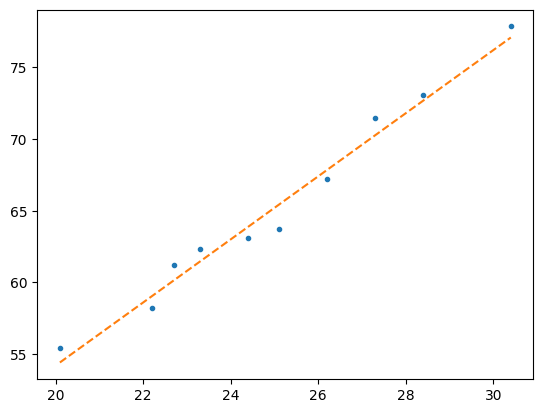

In [ ]:
plt.plot(x, y, '.')
plt.plot(x, 10.2 + 2.2*x, '--')

In [ ]:
# 오차의 비교
sum1 = 0
for i in range(10):
    sum1 = sum1 + (y[i] - 15 - 2*x[i]) ** 2  # 갑이 더 작다.

In [ ]:
sum2 = 0
for i in range(10):
    sum2 = sum2 + (y[i] - 14 - 2*x[i]) ** 2

In [ ]:
sum1, sum2

(<tf.Tensor: shape=(), dtype=float32, numpy=14.734169006347656>,
 <tf.Tensor: shape=(), dtype=float32, numpy=31.521087646484375>)

In [ ]:
# 따라서 최적의 추정치를 이용한 추세선을 아래와 같이 계산할 수 있음.
Sxx = sum((x - sum(x) / 10)**2)
Sxx

<tf.Tensor: shape=(), dtype=float32, numpy=87.8489761352539>

In [ ]:
Sxy = sum((x-sum(x)/10)*(y-sum(y)/10))
Sxy

<tf.Tensor: shape=(), dtype=float32, numpy=194.64736938476562>

In [ ]:
beta1_estimated = Sxy/Sxx
beta1_estimated

<tf.Tensor: shape=(), dtype=float32, numpy=2.2157044410705566>

In [ ]:
beta0_estimated = sum(y)/10 - beta1_estimated*sum(x)/10
beta0_estimated

<tf.Tensor: shape=(), dtype=float32, numpy=9.944572448730469>

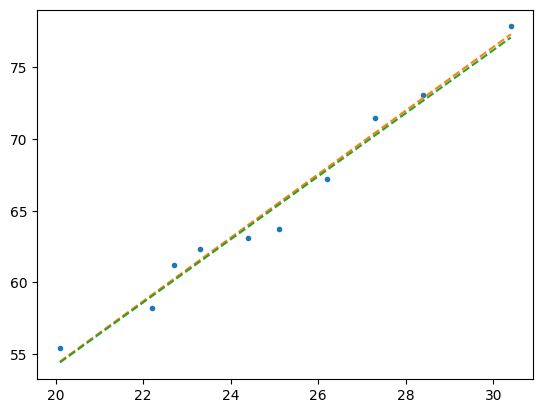

In [ ]:
plt.plot(x, y, '.')
plt.plot(x, beta0_estimated + beta1_estimated * x, '--')
plt.plot(x, 10.2 + 2.2*x, '--')

In [ ]:
# matrix 형태로 적용
X = tf.transpose(tf.concat([[[1.0]*10], [x]], 0))
X

<tf.Tensor: shape=(10, 2), dtype=float32, numpy=
array([[ 1. , 20.1],
       [ 1. , 22.2],
       [ 1. , 22.7],
       [ 1. , 23.3],
       [ 1. , 24.4],
       [ 1. , 25.1],
       [ 1. , 26.2],
       [ 1. , 27.3],
       [ 1. , 28.4],
       [ 1. , 30.4]], dtype=float32)>

In [ ]:
# (X를 만드는 방법2)
from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()

In [ ]:
X = tf.concat([[[1.0]*10], [x]], 0).T
X

<tf.Tensor: shape=(10, 2), dtype=float32, numpy=
array([[ 1. , 20.1],
       [ 1. , 22.2],
       [ 1. , 22.7],
       [ 1. , 23.3],
       [ 1. , 24.4],
       [ 1. , 25.1],
       [ 1. , 26.2],
       [ 1. , 27.3],
       [ 1. , 28.4],
       [ 1. , 30.4]], dtype=float32)>

In [ ]:
tf.linalg.inv(X.T @ X) @ X.T @ y

<tf.Tensor: shape=(2,), dtype=float32, numpy=array([9.944702, 2.215706], dtype=float32)>

## Lecture_02(2주차)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import numpy as np

In [ ]:
tf.config.experimental.list_logical_devices('GPU')  # check GPU

[LogicalDevice(name='/device:GPU:0', device_type='GPU')]

In [ ]:
lst = [1,2]
lst

[1, 2]

In [ ]:
lst[0]

1

In [ ]:
# (2,2) matrix
lst = [[1,2],[3,4]]
lst

[[1, 2], [3, 4]]

In [ ]:
lst[0][0]

1

In [ ]:
# (4,1) matrix
lst = [[1,2],[3,4],[5,6],[7,8]]
lst   # (4,2)

[[1, 2], [3, 4], [5, 6], [7, 8]]

In [ ]:
lst = [[1],[2],[3],[4]]
lst   # (4,1)

[[1], [2], [3], [4]]

In [ ]:
lst = [[1,2,3,4],[5,6,7,8]]
lst   # (2,4)

[[1, 2, 3, 4], [5, 6, 7, 8]]

In [ ]:
# 3차원
lst = [[[1,2],[3,4]],[[5,6],[7,8]]]
lst  # (2,2,2)

[[[1, 2], [3, 4]], [[5, 6], [7, 8]]]

In [ ]:
# 스칼라
_scalar = tf.constant(1)
_scalar

<tf.Tensor: shape=(), dtype=int32, numpy=1>

In [ ]:
# 벡터
_vector = tf.constant([1,2,3])
_vector

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([1, 2, 3], dtype=int32)>

In [ ]:
_vector[-1]

<tf.Tensor: shape=(), dtype=int32, numpy=3>

In [ ]:
# 매트릭스
_matrix = tf.constant([[1,2], [3,4]])
_matrix

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[1, 2],
       [3, 4]], dtype=int32)>

In [ ]:
_matrix[0,1]

<tf.Tensor: shape=(), dtype=int32, numpy=2>

In [ ]:
# 타입
type(_scalar)

tensorflow.python.framework.ops.EagerTensor

In [ ]:
# 인덱싱
_matrix = tf.constant([[1,2,3],[3,4,5]])
_matrix

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[1, 2, 3],
       [3, 4, 5]], dtype=int32)>

In [ ]:
_matrix[0,:]

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([1, 2, 3], dtype=int32)>

In [ ]:
_matrix[:,0]

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([1, 3], dtype=int32)>

In [ ]:
_matrix[:,-1]

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([3, 5], dtype=int32)>

### tf.constant는 불편하다. -> Numpy로 바꾸기

In [ ]:
# 값을 바꿀 수 없다.
_matrix =tf.constant([[1,2,3],[3,4,5]])
_matrix

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[1, 2, 3],
       [3, 4, 5]], dtype=int32)>

In [ ]:
# _matrix[0,0] = 22  -> 에러발생

In [ ]:
# dtype이 다르면 연산이 불가능함
# tf.constant([1,2.2]) + tf.constant([3,4])

In [ ]:
tf.constant([1.1,2]) + tf.constant([3.0,4.0])

<tf.Tensor: shape=(2,), dtype=float32, numpy=array([4.1, 6. ], dtype=float32)>

### tf.constant -> 넘파이

In [ ]:
_vector = tf.constant([1,2,3,4])
_vector

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([1, 2, 3, 4], dtype=int32)>

In [ ]:
np.array(_vector)   # 방법1

array([1, 2, 3, 4], dtype=int32)

In [ ]:
_vector.numpy()

array([1, 2, 3, 4], dtype=int32)

### 연산

In [ ]:
# 더하기
a = tf.constant([1,2,3])
b = tf.constant([4,5,6])
a + b

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([5, 7, 9], dtype=int32)>

In [ ]:
tf.add(a, b)

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([5, 7, 9], dtype=int32)>

In [ ]:
# 곱하기
a = tf.constant([[1,2],[3,4]])
b = tf.constant([[4,5],[6,7]])
a * b

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 4, 10],
       [18, 28]], dtype=int32)>

In [ ]:
tf.multiply(a, b)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 4, 10],
       [18, 28]], dtype=int32)>

In [ ]:
# 행렬곱
a = tf.constant([[1,0],[0,1]])
b = tf.constant([[1],[22]])
a @ b

<tf.Tensor: shape=(2, 1), dtype=int32, numpy=
array([[ 1],
       [22]], dtype=int32)>

In [ ]:
# b @ a   # 행과 열의 갯수가 맞지 않음

In [ ]:
tf.matmul(a, b)

<tf.Tensor: shape=(2, 1), dtype=int32, numpy=
array([[ 1],
       [22]], dtype=int32)>

In [ ]:
# 역행렬
a = tf.constant([[1,0],[0,2]])
a

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[1, 0],
       [0, 2]], dtype=int32)>

In [ ]:
# tf.linalg.inv(a)   # 계산 중 데이터 타입이 일치하지 않음

In [ ]:
a = tf.constant([[1.0,2.0],[3.0,4.0]])
tf.linalg.inv(a)

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[-2. ,  1. ],
       [ 1.5, -0.5]], dtype=float32)>

In [ ]:
a @ tf.linalg.inv(a)

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[1., 0.],
       [0., 1.]], dtype=float32)>

In [ ]:
a = tf.constant([[1.0,2.0],[3.0,4.0]])
tf.linalg.det(a)

<tf.Tensor: shape=(), dtype=float32, numpy=-2.0>

In [ ]:
tf.linalg.trace(a)

<tf.Tensor: shape=(), dtype=float32, numpy=5.0>

### 단순한 집계함수들

In [ ]:
a = tf.constant([[1,2,3],[4,5,6]])
a

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[1, 2, 3],
       [4, 5, 6]], dtype=int32)>

In [ ]:
tf.reduce_sum(a)

<tf.Tensor: shape=(), dtype=int32, numpy=21>

In [ ]:
tf.reduce_max(a)

<tf.Tensor: shape=(), dtype=int32, numpy=6>

### 행렬곱 고급

In [ ]:
_l = tf.constant([[1.0,0.0],[0.0,1.0]])
_l

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[1., 0.],
       [0., 1.]], dtype=float32)>

In [ ]:
_x = tf.constant([22.0,33.0])
_x

<tf.Tensor: shape=(2,), dtype=float32, numpy=array([22., 33.], dtype=float32)>

In [ ]:
# _I @ _x   # 행과 열의 갯수가 맞지 않아서 연산이 안됨

In [ ]:
_x = tf.constant([[1.0],[2.0]])
_x

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[1.],
       [2.]], dtype=float32)>

In [ ]:
_l @ _x

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[1.],
       [2.]], dtype=float32)>

### 형태변환

In [ ]:
#  tf.reshape 기본
a = tf.constant([1,2,3,4])
a

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([1, 2, 3, 4], dtype=int32)>

In [ ]:
tf.reshape(a, [2,2])

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[1, 2],
       [3, 4]], dtype=int32)>

In [ ]:
tf.reshape(a, [4,1])

<tf.Tensor: shape=(4, 1), dtype=int32, numpy=
array([[1],
       [2],
       [3],
       [4]], dtype=int32)>

### 선언고급

In [ ]:
# 대각행렬선언
tf.constant(np.diag([1,2,3]))

<tf.Tensor: shape=(3, 3), dtype=int64, numpy=
array([[1, 0, 0],
       [0, 2, 0],
       [0, 0, 3]])>

In [ ]:
# 1만 포함한 텐서를 만들고 싶음
tf.ones([3,4])

<tf.Tensor: shape=(3, 4), dtype=float32, numpy=
array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]], dtype=float32)>

## Lecture_03(3주차)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import numpy as np

In [ ]:
tf.config.experimental.list_logical_devices('GPU')

[LogicalDevice(name='/device:GPU:0', device_type='GPU')]

### 배열선언

In [ ]:
tf.constant(range(12))

<tf.Tensor: shape=(12,), dtype=int32, numpy=array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], dtype=int32)>

In [ ]:
tf.constant(range(2,6))

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([2, 3, 4, 5], dtype=int32)>

In [ ]:
tf.constant(range(2,21,3))

<tf.Tensor: shape=(7,), dtype=int32, numpy=array([ 2,  5,  8, 11, 14, 17, 20], dtype=int32)>

In [ ]:
tf.linspace(0,1,14)

<tf.Tensor: shape=(14,), dtype=float64, numpy=
array([0.        , 0.07692308, 0.15384615, 0.23076923, 0.30769231,
       0.38461538, 0.46153846, 0.53846154, 0.61538462, 0.69230769,
       0.76923077, 0.84615385, 0.92307692, 1.        ])>

In [ ]:
tf.linspace(-1,20,14)

<tf.Tensor: shape=(14,), dtype=float64, numpy=
array([-1.        ,  0.61538462,  2.23076923,  3.84615385,  5.46153846,
        7.07692308,  8.69230769, 10.30769231, 11.92307692, 13.53846154,
       15.15384615, 16.76923077, 18.38461538, 20.        ])>

In [ ]:
tf.linspace([0,-1],[1,20], 14, axis=0)

<tf.Tensor: shape=(14, 2), dtype=float64, numpy=
array([[ 0.        , -1.        ],
       [ 0.07692308,  0.61538462],
       [ 0.15384615,  2.23076923],
       [ 0.23076923,  3.84615385],
       [ 0.30769231,  5.46153846],
       [ 0.38461538,  7.07692308],
       [ 0.46153846,  8.69230769],
       [ 0.53846154, 10.30769231],
       [ 0.61538462, 11.92307692],
       [ 0.69230769, 13.53846154],
       [ 0.76923077, 15.15384615],
       [ 0.84615385, 16.76923077],
       [ 0.92307692, 18.38461538],
       [ 1.        , 20.        ]])>

In [ ]:
tf.linspace([0,-1],[1,20], 14, axis=1)

<tf.Tensor: shape=(2, 14), dtype=float64, numpy=
array([[ 0.        ,  0.07692308,  0.15384615,  0.23076923,  0.30769231,
         0.38461538,  0.46153846,  0.53846154,  0.61538462,  0.69230769,
         0.76923077,  0.84615385,  0.92307692,  1.        ],
       [-1.        ,  0.61538462,  2.23076923,  3.84615385,  5.46153846,
         7.07692308,  8.69230769, 10.30769231, 11.92307692, 13.53846154,
        15.15384615, 16.76923077, 18.38461538, 20.        ]])>

### 랜덤

In [ ]:
tf.random.normal([3,3])

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[-0.237811  ,  0.44766426, -0.22368717],
       [-0.91082186, -0.21936591, -0.12378943],
       [-0.7576514 ,  0.8017605 ,  0.09748111]], dtype=float32)>

In [ ]:
tf.random.normal([10])

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 0.18130144, -0.6556629 , -1.0432014 ,  0.06268173, -1.2917681 ,
       -0.5719799 , -0.06176966, -1.1217493 ,  0.2757861 , -0.13597581],
      dtype=float32)>

In [ ]:
tf.random.uniform([3,3])

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[0.3569386 , 0.5754032 , 0.79122305],
       [0.770942  , 0.2492832 , 0.6663885 ],
       [0.35701275, 0.13733459, 0.19903398]], dtype=float32)>

In [ ]:
np.random.randn(10)

array([ 0.09787215,  1.80339279, -0.50827243,  1.82339518, -0.55006408,
       -0.58547164,  0.60590139,  0.33067935, -1.35852626, -0.51736744])

In [ ]:
# tf.random.randn(10)   안됨

### tf.concat

In [ ]:
a = tf.constant([[1],[2]])  # (2,1)
b = tf.constant([[3],[4]])  # (2,1)

In [ ]:
tf.concat([a,b], axis=1)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[1, 3],
       [2, 4]], dtype=int32)>

In [ ]:
a = tf.constant([[1,2]])  # (1,2)
b = tf.constant([[3,4]])  # (1,2)

In [ ]:
tf.concat([a,b], axis=0)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[1, 2],
       [3, 4]], dtype=int32)>

In [ ]:
tf.concat([a,b], axis=1)

<tf.Tensor: shape=(1, 4), dtype=int32, numpy=array([[1, 2, 3, 4]], dtype=int32)>

In [ ]:
a = tf.reshape(tf.constant(range(12)), (2,2,3) )
b = -a
a,b

(<tf.Tensor: shape=(2, 2, 3), dtype=int32, numpy=
 array([[[ 0,  1,  2],
         [ 3,  4,  5]],
 
        [[ 6,  7,  8],
         [ 9, 10, 11]]], dtype=int32)>,
 <tf.Tensor: shape=(2, 2, 3), dtype=int32, numpy=
 array([[[  0,  -1,  -2],
         [ -3,  -4,  -5]],
 
        [[ -6,  -7,  -8],
         [ -9, -10, -11]]], dtype=int32)>)

In [ ]:
tf.concat([a,b], axis=0)  # (4, 2, 3)

<tf.Tensor: shape=(4, 2, 3), dtype=int32, numpy=
array([[[  0,   1,   2],
        [  3,   4,   5]],

       [[  6,   7,   8],
        [  9,  10,  11]],

       [[  0,  -1,  -2],
        [ -3,  -4,  -5]],

       [[ -6,  -7,  -8],
        [ -9, -10, -11]]], dtype=int32)>

In [ ]:
tf.concat([a,b], axis=1)   # (2, 4, 3)

<tf.Tensor: shape=(2, 4, 3), dtype=int32, numpy=
array([[[  0,   1,   2],
        [  3,   4,   5],
        [  0,  -1,  -2],
        [ -3,  -4,  -5]],

       [[  6,   7,   8],
        [  9,  10,  11],
        [ -6,  -7,  -8],
        [ -9, -10, -11]]], dtype=int32)>

In [ ]:
tf.concat([a,b], axis=-1)   # or axis=2   # (2, 2, 6)

<tf.Tensor: shape=(2, 2, 6), dtype=int32, numpy=
array([[[  0,   1,   2,   0,  -1,  -2],
        [  3,   4,   5,  -3,  -4,  -5]],

       [[  6,   7,   8,  -6,  -7,  -8],
        [  9,  10,  11,  -9, -10, -11]]], dtype=int32)>

### tf.stack -> 차원을 증가시키면서 결합

In [ ]:
a = tf.constant([1,2,3,4])
b = -a
a,b

(<tf.Tensor: shape=(4,), dtype=int32, numpy=array([1, 2, 3, 4], dtype=int32)>,
 <tf.Tensor: shape=(4,), dtype=int32, numpy=array([-1, -2, -3, -4], dtype=int32)>)

In [ ]:
tf.stack([a,b], axis=0)

<tf.Tensor: shape=(2, 4), dtype=int32, numpy=
array([[ 1,  2,  3,  4],
       [-1, -2, -3, -4]], dtype=int32)>

In [ ]:
tf.stack([a,b], axis=1)

<tf.Tensor: shape=(4, 2), dtype=int32, numpy=
array([[ 1, -1],
       [ 2, -2],
       [ 3, -3],
       [ 4, -4]], dtype=int32)>

### 첫번째축이 비어있다고 인식(reshape)

In [ ]:
a = tf.reshape(tf.constant(range(2*3*4*5)), (2,3,4,5))
b = -a
a,b   # (2, 3, 4, 5), (2, 3, 4, 5)

(<tf.Tensor: shape=(2, 3, 4, 5), dtype=int32, numpy=
 array([[[[  0,   1,   2,   3,   4],
          [  5,   6,   7,   8,   9],
          [ 10,  11,  12,  13,  14],
          [ 15,  16,  17,  18,  19]],
 
         [[ 20,  21,  22,  23,  24],
          [ 25,  26,  27,  28,  29],
          [ 30,  31,  32,  33,  34],
          [ 35,  36,  37,  38,  39]],
 
         [[ 40,  41,  42,  43,  44],
          [ 45,  46,  47,  48,  49],
          [ 50,  51,  52,  53,  54],
          [ 55,  56,  57,  58,  59]]],
 
 
        [[[ 60,  61,  62,  63,  64],
          [ 65,  66,  67,  68,  69],
          [ 70,  71,  72,  73,  74],
          [ 75,  76,  77,  78,  79]],
 
         [[ 80,  81,  82,  83,  84],
          [ 85,  86,  87,  88,  89],
          [ 90,  91,  92,  93,  94],
          [ 95,  96,  97,  98,  99]],
 
         [[100, 101, 102, 103, 104],
          [105, 106, 107, 108, 109],
          [110, 111, 112, 113, 114],
          [115, 116, 117, 118, 119]]]], dtype=int32)>,
 <tf.Tensor: shape=(2, 

In [ ]:
tf.stack([a,b], axis=0)   # (2, 2, 3, 4, 5)

<tf.Tensor: shape=(2, 2, 3, 4, 5), dtype=int32, numpy=
array([[[[[   0,    1,    2,    3,    4],
          [   5,    6,    7,    8,    9],
          [  10,   11,   12,   13,   14],
          [  15,   16,   17,   18,   19]],

         [[  20,   21,   22,   23,   24],
          [  25,   26,   27,   28,   29],
          [  30,   31,   32,   33,   34],
          [  35,   36,   37,   38,   39]],

         [[  40,   41,   42,   43,   44],
          [  45,   46,   47,   48,   49],
          [  50,   51,   52,   53,   54],
          [  55,   56,   57,   58,   59]]],


        [[[  60,   61,   62,   63,   64],
          [  65,   66,   67,   68,   69],
          [  70,   71,   72,   73,   74],
          [  75,   76,   77,   78,   79]],

         [[  80,   81,   82,   83,   84],
          [  85,   86,   87,   88,   89],
          [  90,   91,   92,   93,   94],
          [  95,   96,   97,   98,   99]],

         [[ 100,  101,  102,  103,  104],
          [ 105,  106,  107,  108,  109],
         

In [ ]:
tf.stack([a,b], axis=1)    # (2, 2, 3, 4, 5)

<tf.Tensor: shape=(2, 2, 3, 4, 5), dtype=int32, numpy=
array([[[[[   0,    1,    2,    3,    4],
          [   5,    6,    7,    8,    9],
          [  10,   11,   12,   13,   14],
          [  15,   16,   17,   18,   19]],

         [[  20,   21,   22,   23,   24],
          [  25,   26,   27,   28,   29],
          [  30,   31,   32,   33,   34],
          [  35,   36,   37,   38,   39]],

         [[  40,   41,   42,   43,   44],
          [  45,   46,   47,   48,   49],
          [  50,   51,   52,   53,   54],
          [  55,   56,   57,   58,   59]]],


        [[[   0,   -1,   -2,   -3,   -4],
          [  -5,   -6,   -7,   -8,   -9],
          [ -10,  -11,  -12,  -13,  -14],
          [ -15,  -16,  -17,  -18,  -19]],

         [[ -20,  -21,  -22,  -23,  -24],
          [ -25,  -26,  -27,  -28,  -29],
          [ -30,  -31,  -32,  -33,  -34],
          [ -35,  -36,  -37,  -38,  -39]],

         [[ -40,  -41,  -42,  -43,  -44],
          [ -45,  -46,  -47,  -48,  -49],
         

In [ ]:
tf.stack([a,b], axis=-1)    # (2, 3, 4, 5, 2)

<tf.Tensor: shape=(2, 3, 4, 5, 2), dtype=int32, numpy=
array([[[[[   0,    0],
          [   1,   -1],
          [   2,   -2],
          [   3,   -3],
          [   4,   -4]],

         [[   5,   -5],
          [   6,   -6],
          [   7,   -7],
          [   8,   -8],
          [   9,   -9]],

         [[  10,  -10],
          [  11,  -11],
          [  12,  -12],
          [  13,  -13],
          [  14,  -14]],

         [[  15,  -15],
          [  16,  -16],
          [  17,  -17],
          [  18,  -18],
          [  19,  -19]]],


        [[[  20,  -20],
          [  21,  -21],
          [  22,  -22],
          [  23,  -23],
          [  24,  -24]],

         [[  25,  -25],
          [  26,  -26],
          [  27,  -27],
          [  28,  -28],
          [  29,  -29]],

         [[  30,  -30],
          [  31,  -31],
          [  32,  -32],
          [  33,  -33],
          [  34,  -34]],

         [[  35,  -35],
          [  36,  -36],
          [  37,  -37],
          [  38, 

## Lecture_04(4주차)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import tensorflow.experimental.numpy as tnp

In [3]:
import matplotlib.pyplot as plt

In [4]:
tnp.experimental_enable_numpy_behavior()

### 미분

#### tf.GradientTape() 사용방법

In [5]:
x=tnp.array([20.1, 22.2, 22.7, 23.3, 24.4, 25.1, 26.2, 27.3, 28.4, 30.4])
x

<tf.Tensor: shape=(10,), dtype=float64, numpy=array([20.1, 22.2, 22.7, 23.3, 24.4, 25.1, 26.2, 27.3, 28.4, 30.4])>

In [7]:
tnp.random.seed(10)
y = 10.2 + x*2.2 + tnp.random.randn(10)
y

<tf.Tensor: shape=(10,), dtype=float64, numpy=
array([56.17900312, 59.85106225, 62.79023267, 62.53326695, 63.02763381,
       65.27836329, 66.18667565, 72.47715148, 71.55623798, 78.57941939])>

In [8]:
beta0=tf.Variable(9.0)
beta1=tf.Variable(2.0)

In [9]:
with tf.GradientTape(persistent=True) as tape:
    loss = sum((y-beta0-beta1*x)**2)

In [10]:
tape.gradient(loss, beta0), tape.gradient(loss, beta1)

(<tf.Tensor: shape=(), dtype=float32, numpy=-136.51809692382812>,
 <tf.Tensor: shape=(), dtype=float32, numpy=-3427.489501953125>)

#### 예제10: 카페예제의 매트릭스 버전

In [12]:
X=tnp.array([1]*10 + [20.1, 22.2, 22.7, 23.3, 24.4, 25.1, 26.2, 27.3, 28.4, 30.4]).reshape(2,10).T
X

<tf.Tensor: shape=(10, 2), dtype=float64, numpy=
array([[ 1. , 20.1],
       [ 1. , 22.2],
       [ 1. , 22.7],
       [ 1. , 23.3],
       [ 1. , 24.4],
       [ 1. , 25.1],
       [ 1. , 26.2],
       [ 1. , 27.3],
       [ 1. , 28.4],
       [ 1. , 30.4]])>

In [14]:
beta_true = tnp.array([[10.2], [2.2]])
beta_true

<tf.Tensor: shape=(2, 1), dtype=float64, numpy=
array([[10.2],
       [ 2.2]])>

In [15]:
tnp.random.seed(10)
y = X@beta_true # (10,2)x(2,1)=(10,1)

In [16]:
y = X@beta_true + tnp.random.randn(10).reshape(10,1)
y

<tf.Tensor: shape=(10, 1), dtype=float64, numpy=
array([[56.17900312],
       [59.85106225],
       [62.79023267],
       [62.53326695],
       [63.02763381],
       [65.27836329],
       [66.18667565],
       [72.47715148],
       [71.55623798],
       [78.57941939]])>

In [17]:
beta = tnp.array([[9.0], [2.0]])  # (2,1)
beta

<tf.Tensor: shape=(2, 1), dtype=float64, numpy=
array([[9.],
       [2.]])>

In [18]:
with tf.GradientTape(persistent=True) as tape:
    tape.watch(beta)
    yhat = X@beta  # (10,2)x(2,1)=(10,1)
    loss = (y-yhat).T @ (y-yhat)

In [19]:
tape.gradient(loss, beta)  # 텐서플로우가 계산한 미분값

<tf.Tensor: shape=(2, 1), dtype=float64, numpy=
array([[ -136.51809321],
       [-3427.48955131]])>

#### min (loss & value)

In [20]:
# 여기서 최적값(최소값)을 찾고 이 때의 loss 값을 구해서 그 값이 0에 수렴하는지 확인

In [ ]:
import tensorflow as tf
import tensorflow.experimental.numpy as tnp

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
tnp.experimental_enable_numpy_behavior()

#### 미분

In [ ]:
# tf.GradientTape() 사용방법
x=tnp.array([20.1, 22.2, 22.7, 23.3, 24.4, 25.1, 26.2, 27.3, 28.4, 30.4])
x

<tf.Tensor: shape=(10,), dtype=float64, numpy=array([20.1, 22.2, 22.7, 23.3, 24.4, 25.1, 26.2, 27.3, 28.4, 30.4])>

In [ ]:
tnp.random.seed(43052)
y = 10.2 + 2.2 * x + tnp.random.randn(10)
y

<tf.Tensor: shape=(10,), dtype=float64, numpy=
array([54.98269924, 60.27348365, 61.27621687, 60.53495888, 62.9770905 ,
       66.32168996, 66.87781372, 71.0050025 , 72.63837337, 77.11143943])>

In [ ]:
beta0 = tf.Variable(9.0)
beta1 = tf.Variable(2.0)

In [ ]:
with tf.GradientTape(persistent=True) as tape:
    loss = sum((y - beta0 - beta1 * x)**2)

In [ ]:
tape.gradient(loss, beta0), tape.gradient(loss, beta1)

(<tf.Tensor: shape=(), dtype=float32, numpy=-127.5975341796875>,
 <tf.Tensor: shape=(), dtype=float32, numpy=-3214.253173828125>)

In [ ]:
# 예제10: 카페예제의 매트릭스 버전
X= tnp.array([1]*10+ [20.1, 22.2, 22.7, 23.3, 24.4, 25.1, 26.2, 27.3, 28.4, 30.4]).reshape(2,10).T
X

<tf.Tensor: shape=(10, 2), dtype=float64, numpy=
array([[ 1. , 20.1],
       [ 1. , 22.2],
       [ 1. , 22.7],
       [ 1. , 23.3],
       [ 1. , 24.4],
       [ 1. , 25.1],
       [ 1. , 26.2],
       [ 1. , 27.3],
       [ 1. , 28.4],
       [ 1. , 30.4]])>

In [ ]:
beta_true = tnp.array([[10.2], [2.2]])
beta_true

<tf.Tensor: shape=(2, 1), dtype=float64, numpy=
array([[10.2],
       [ 2.2]])>

In [ ]:
tnp.random.seed(43052)
y = X@beta_true + tnp.random.randn(10).reshape(10,1)
y

<tf.Tensor: shape=(10, 1), dtype=float64, numpy=
array([[54.98269924],
       [60.27348365],
       [61.27621687],
       [60.53495888],
       [62.9770905 ],
       [66.32168996],
       [66.87781372],
       [71.0050025 ],
       [72.63837337],
       [77.11143943]])>

In [ ]:
tnp.random.seed(43052)
y = X@beta_true + tnp.random.randn(10).reshape(10,1)
y

<tf.Tensor: shape=(10, 1), dtype=float64, numpy=
array([[54.98269924],
       [60.27348365],
       [61.27621687],
       [60.53495888],
       [62.9770905 ],
       [66.32168996],
       [66.87781372],
       [71.0050025 ],
       [72.63837337],
       [77.11143943]])>

In [ ]:
beta = tnp.array([[9.0],[2.2]])
beta

<tf.Tensor: shape=(2, 1), dtype=float64, numpy=
array([[9. ],
       [2.2]])>

In [ ]:
with tf.GradientTape(persistent=True) as tape:
    tape.watch(beta)
    yhat = X@beta
    loss = (y-yhat).T @ (y-yhat)

In [ ]:
tape.gradient(loss, beta)

<tf.Tensor: shape=(2, 1), dtype=float64, numpy=
array([[ -27.55753624],
       [-677.11306574]])>

In [ ]:
# 해석적풀이
-2 * X.T @ y + 2 * X.T @ X @ beta   #  이론적인 값

<tf.Tensor: shape=(2, 1), dtype=float64, numpy=
array([[ -27.55753624],
       [-677.11306574]])>

#### 예제11: 위의 예제에서 이론적인
의 최적값을 찾아보고 (즉
을 찾고) 그 지점에서 loss의 미분값(=접선의 기울기)를 구하라. 결과가
인지 확인하라. (단
은 길이가 2이고 각 원소가 0인 벡터)

In [ ]:
betahat = tf.linalg.inv(X.T @ X) @ X.T @ y
betahat

<tf.Tensor: shape=(2, 1), dtype=float64, numpy=
array([[12.10040012],
       [ 2.13112662]])>

In [ ]:
with tf.GradientTape(persistent=True) as tape:
    tape.watch(betahat)
    yhat = X@betahat
    loss = (y - yhat).T @ (y - yhat)

In [ ]:
tape.gradient(loss, betahat)

<tf.Tensor: shape=(2, 1), dtype=float64, numpy=
array([[-5.57065505e-12],
       [-1.40795819e-10]])>

### 경사하강법

#### 최적화문제

In [ ]:
# 방법1: grid search
beta = tnp.linspace(-10, 10, 100)
loss = (beta/2 - 1)**2

In [ ]:
loss

<tf.Tensor: shape=(100,), dtype=float64, numpy=
array([3.60000000e+01, 3.47980818e+01, 3.36165697e+01, 3.24554637e+01,
       3.13147638e+01, 3.01944700e+01, 2.90945822e+01, 2.80151005e+01,
       2.69560249e+01, 2.59173554e+01, 2.48990919e+01, 2.39012346e+01,
       2.29237833e+01, 2.19667381e+01, 2.10300990e+01, 2.01138659e+01,
       1.92180390e+01, 1.83426181e+01, 1.74876033e+01, 1.66529946e+01,
       1.58387920e+01, 1.50449954e+01, 1.42716049e+01, 1.35186205e+01,
       1.27860422e+01, 1.20738700e+01, 1.13821039e+01, 1.07107438e+01,
       1.00597898e+01, 9.42924191e+00, 8.81910009e+00, 8.22936435e+00,
       7.66003469e+00, 7.11111111e+00, 6.58259361e+00, 6.07448220e+00,
       5.58677686e+00, 5.11947760e+00, 4.67258443e+00, 4.24609734e+00,
       3.84001632e+00, 3.45434139e+00, 3.08907254e+00, 2.74420977e+00,
       2.41975309e+00, 2.11570248e+00, 1.83205795e+00, 1.56881951e+00,
       1.32598714e+00, 1.10356086e+00, 9.01540659e-01, 7.19926538e-01,
       5.58718498e-01, 4.1791

In [ ]:
# (예비학습)
tnp.argmin([1,2,3,-1,5])

<tf.Tensor: shape=(), dtype=int64, numpy=3>

In [ ]:
tnp.argmin([1,2,-1,3,5])

<tf.Tensor: shape=(), dtype=int64, numpy=2>

In [ ]:
tnp.argmin(loss)

<tf.Tensor: shape=(), dtype=int64, numpy=59>

In [ ]:
beta[59]

<tf.Tensor: shape=(), dtype=float64, numpy=1.9191919191919187>

In [ ]:
beta[60]

<tf.Tensor: shape=(), dtype=float64, numpy=2.121212121212121>

In [ ]:
loss[59], loss[60]

(<tf.Tensor: shape=(), dtype=float64, numpy=0.0016324864809713507>,
 <tf.Tensor: shape=(), dtype=float64, numpy=0.0036730945821854847>)